In [94]:
!pip install pyts

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   - -------------------------------------- 0.1/2.5 MB 3.3 MB/s eta 0:00:01
   ---- ----------------------------------- 0.3/2.5 MB 3.1 MB/s eta 0:00:01
   ------ --------------------------------- 0.4/2.5 MB 3.4 MB/s eta 0:00:01
   ------------ --------------------------- 0.8/2.5 MB 4.3 MB/s eta 0:00:01
   -------------- ------------------------- 1.0/2.5 MB 4.3 MB/s eta 0:00:01
   ------------------- -------------------- 1.3/2.5 MB 4.5 MB/s eta 0:00:01
   ------------------------- -------------- 1.6/2.5 MB 4.8 MB/s eta 0:00:01
   ----------------------------- ---------- 1.9/2.5 MB 5.2 MB/s eta 0:00:01
   ---------------------------------- ----- 2.2/2.5 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------  2.5/2.5 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 5.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   -- --------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\lenovo\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyts.image import RecurrencePlot
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
df = pd.read_csv("E:/CoDaS Project/Radar/C3/radar_interpolated_merged_data.csv")

In [3]:
df.head()

,user_id,emotion,timestamp,x_0,y_0,z_0,x_1,y_1,z_1,x_2,...,z_9,x_10,y_10,z_10,x_11,y_11,z_11,x_12,y_12,z_12
0,U03,E01,0.0,-1.552832,2.019133,3.019763,1.598392,2.063676,2.730807,-0.111990,...,0.990396,1.264181,-1.402791,1.851254,-0.120669,-1.867145,1.639876,-0.896563,-1.647700,1.269290
1,U03,E01,0.1,-1.556085,2.018850,3.017850,1.600228,2.062156,2.729698,-0.112344,...,0.992052,1.265696,-1.400110,1.848140,-0.118074,-1.865452,1.638204,-0.894944,-1.649004,1.268658
2,U03,E01,0.2,-1.559314,2.018575,3.015951,1.602051,2.060658,2.728599,-0.112690,...,0.993693,1.267198,-1.397449,1.845054,-0.115504,-1.863768,1.636547,-0.893336,-1.650296,1.268033
3,U03,E01,0.3,-1.562517,2.018308,3.014067,1.603860,2.059181,2.727511,-0.113030,...,0.995320,1.268687,-1.394810,1.841994,-0.112958,-1.862093,1.634905,-0.891740,-1.651574,1.267417
4,U03,E01,0.4,-1.565695,2.018048,3.012197,1.605657,2.057725,2.726434,-0.113363,...,0.996934,1.270164,-1.392192,1.838961,-0.110436,-1.860427,1.633277,-0.890155,-1.652840,1.266810


In [ ]:
# Code for generating recurrence plots of entire sequences for each user and emotion, and saving them as images and numpy array
image_size=128
num_sensors = 13

X=[]
Y=[]
users=[]
for (user_id, emotion), group_data in df.groupby(["user_id","emotion"]):
    #print(f"User ID: {user_id}, Emotion: {emotion}")

    sample_rps = np.zeros((num_sensors*3, image_size, image_size), dtype=np.float64)
    sensors_df=df[(df['user_id'] == user_id) & (df['emotion'] == emotion)]
    for s_id in range(num_sensors):

        # Avoid operations on empty dataframes, 10 samples is an arbitrary threshold
        if len(sensors_df[f"x_{s_id}"].dropna()) == 0:
            continue

        os.makedirs(f"E:/CoDaS Project/Radar/C3_RP/{emotion}/{user_id}", exist_ok=True)
        x_interp = sensors_df[f"x_{s_id}"].values.reshape(1, -1)
        y_interp = sensors_df[f"y_{s_id}"].values.reshape(1, -1)
        z_interp = sensors_df[f"z_{s_id}"].values.reshape(1, -1)

        rp = RecurrencePlot(threshold="point", percentage=20)

        x_rp_image = rp.fit_transform(x_interp)[0]
        y_rp_image = rp.fit_transform(y_interp)[0]
        z_rp_image = rp.fit_transform(z_interp)[0]

        x_rp_image = cv2.resize(x_rp_image, (image_size, image_size))
        y_rp_image = cv2.resize(y_rp_image, (image_size, image_size))
        z_rp_image = cv2.resize(z_rp_image, (image_size, image_size))

        plt.imsave(f"E:/CoDaS Project/Radar/C3_RP/{emotion}/{user_id}/sensor_{s_id}_x.png", x_rp_image, cmap='binary', origin='lower')
        plt.imsave(f"E:/CoDaS Project/Radar/C3_RP/{emotion}/{user_id}/sensor_{s_id}_y.png", y_rp_image, cmap='binary', origin='lower')
        plt.imsave(f"E:/CoDaS Project/Radar/C3_RP/{emotion}/{user_id}/sensor_{s_id}_z.png", z_rp_image, cmap='binary', origin='lower')
        
        sample_rps[3*s_id] = x_rp_image
        sample_rps[3*s_id + 1] = y_rp_image
        sample_rps[3*s_id + 2] = z_rp_image
    np.savez(f"E:/CoDaS Project/Radar/C3_RP/{emotion}/{user_id}/Recurrence_Plots.npz", rps=sample_rps)
    X.append(sample_rps)
    Y.append(emotion)
    users.append(user_id)
    
X = np.stack(X)
Y = np.array(Y)
users = np.array(users)
np.savez("E:/CoDaS Project/Radar/C3_RP_dataset.npz", data=X, labels=Y, users=users)

Text(0, 0.5, 'Time')

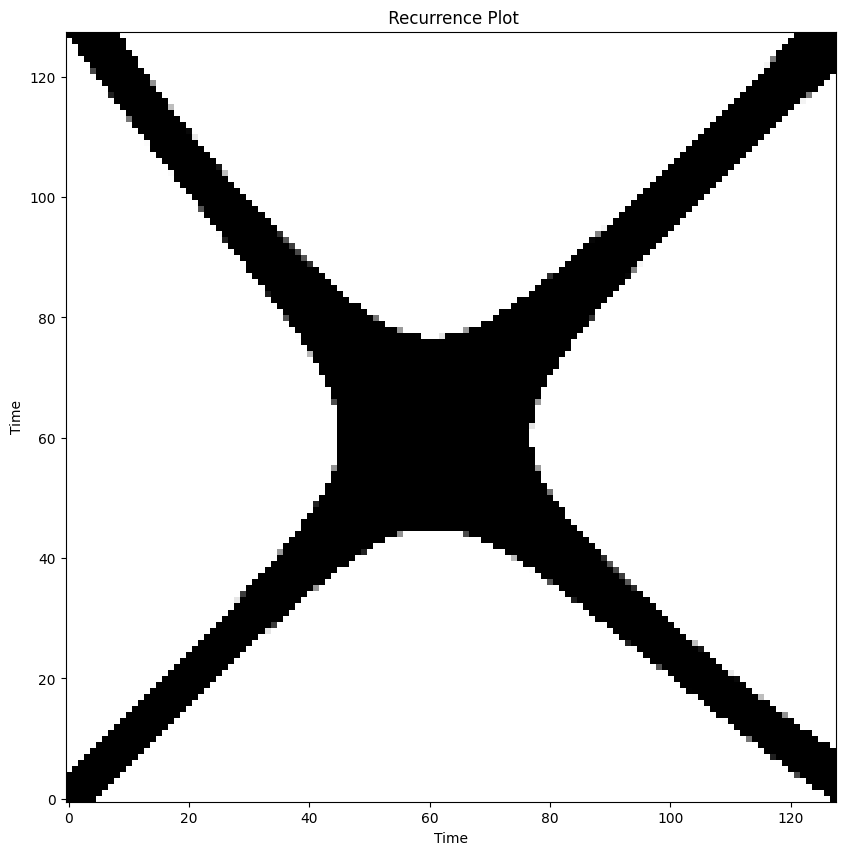

In [5]:
fig, axs = plt.subplots(1, 1, figsize=(12, 10))
axs.imshow(cv2.resize(y_rp_image, (128, 128)), cmap='binary', origin='lower')
axs.set_title(f' Recurrence Plot')
axs.set_xlabel('Time')
axs.set_ylabel('Time')

In [4]:
# Code for generating recurrence plots using sliding windows for each user and emotion, and saving them as images and numpy array
window_length = 6.0
step_size = 6.0
time_length = 0.1
image_size = 128
num_sensors = 13
output_root = r"E:/CoDaS Project/Radar/C3_RP_windows"

samples_per_window = max(1, int(round(window_length / time_length)))
step_samples = max(1, int(round(step_size / time_length)))

rp = RecurrencePlot(threshold="point", percentage=20)

records = []
for (user_id, emotion), group_data in df.groupby(["user_id", "emotion"]):
    group_data = group_data.sort_values("timestamp").reset_index(drop=True)
    total_samples = len(group_data)
    if total_samples < samples_per_window:
        continue

    class_dir = os.path.join(output_root, emotion)
    os.makedirs(class_dir, exist_ok=True)

    sensor_series = []
    for s_id in range(num_sensors):
        x_series_np = group_data[f"x_{s_id}"].to_numpy()
        y_series_np = group_data[f"y_{s_id}"].to_numpy()
        z_series_np = group_data[f"z_{s_id}"].to_numpy()
        sensor_series.append((x_series_np, y_series_np, z_series_np))

    for start in range(0, total_samples - samples_per_window + 1, step_samples):
        end = start + samples_per_window
        window_rps = np.zeros((num_sensors * 3, image_size, image_size), dtype=np.float32)
        
        for s_id, (x_series, y_series, z_series) in enumerate(sensor_series):
        
            # Skip windows with any NaN values in the sensor data
            if np.isnan(x_series).any() or np.isnan(y_series).any() or np.isnan(z_series).any():
                continue

            x_win = x_series[start:end]
            y_win = y_series[start:end]
            z_win = z_series[start:end]

            x_rp = rp.fit_transform(x_win.reshape(1, -1))[0]
            y_rp = rp.fit_transform(y_win.reshape(1, -1))[0]
            z_rp = rp.fit_transform(z_win.reshape(1, -1))[0]

            x_rp = cv2.resize(x_rp, (image_size, image_size))
            y_rp = cv2.resize(y_rp, (image_size, image_size))
            z_rp = cv2.resize(z_rp, (image_size, image_size))

            window_rps[3 * s_id] = x_rp
            window_rps[3 * s_id + 1] = y_rp
            window_rps[3 * s_id + 2] = z_rp

        filename = f"{user_id}_window_{start:05d}_{end:05d}.npz"
        file_path = os.path.join(class_dir, filename)
        np.savez_compressed(
            file_path,
            recurrence_plots=window_rps,
            user_id=user_id,
            emotion=emotion,
            window_start=start,
            window_end=end,
        )

        records.append({
            "user_id": user_id,
            "emotion": emotion,
            "window_start": start,
            "window_end": end,
            "window_length_samples": samples_per_window,
            "step_size_samples": step_samples,
            "file": file_path,
        })

records_df = pd.DataFrame(records)
records_df.to_csv(os.path.join(output_root, "windowed_rp_manifest.csv"), index=False)

In [8]:
records_df = pd.read_csv(r"E:/CoDaS Project/Radar/C3_RP_windows/windowed_rp_manifest.csv")

size=len(records_df)
num_sensors = 13
image_size = 128

combined_rps = np.zeros((size, num_sensors * 3, image_size, image_size), dtype=np.float32)
labels = []
users = []
for idx, row in records_df.iterrows():
    data = np.load(row['file'])
    combined_rps[idx] = data['recurrence_plots']
    labels.append(data['emotion'])
    users.append(data['user_id'])

labels = np.array(labels)
users = np.array(users)
np.savez("E:/CoDaS Project/Radar/C3_RP_windows_dataset.npz",
          data=combined_rps, labels=labels, users=users)